## Importing Libraries

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score
from imblearn import under_sampling, over_sampling
np.random.seed(0)
pd.set_option('display.max_columns', 22)

## Load dataset & Preliminary Look

In [2]:
# Load dataset
df = pd.read_csv('data/fetal_health.csv')

In [3]:
# view dataset
print(df.shape)
df.head()

(2126, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [4]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [5]:
# renaming columns
df.rename(columns = {'baseline value':'baseline_value', 'prolongued_decelerations': 'prolonged_decelerations'}, inplace=True)
df.columns

Index(['baseline_value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolonged_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

**Data dictionary**

* **`baseline value`:** FHR baseline (beats per minute)
* **`accelerations`:** Number of accelerations per second
* **`fetal_movement`:** Number of fetal movements per second
* **`uterine_contractions`:** Number of uterine contractions per second
* **`light_decelerations`:** Number of light decelerations per second
* **`severe_decelerations`:** Number of severe decelerations per second
* **`prolongued_decelerations`:** Number of prolonged decelerations per second
* **`abnormal_short_term_variability`:** Percentage of time with abnormal short term variability
* **`mean_value_of_short_term_variability`:** Mean value of short term variability
* **`percentage_of_time_with_abnormal_long_term_variability`:** Percentage of time with abnormal long term variability
* **`mean_value_of_long_term_variability`:** Mean value of long term variability 
* **`histogram_width`:** Width of FHR histogram
* **`histogram_min`: Minimum** (low frequency) of FHR histogram
* **`histogram_max`: Maximum** (high frequency) of FHR histogram
* **`histogram_number_of_peaks`:** Number of histogram peaks
* **`histogram_number_of_zeroes`:** Number of histogram zeros
* **`histogram_mode`:** Histogram mode
* **`histogram_mean`:** Histogram mean
* **`histogram_median`:** Histogram median
* **`histogram_variance`:** Histogram variance
* **`histogram_tendency`:** Histogram tendency
* **`fetal_health`: (TARGET)**  Fetal health as assessed by expert obstetrician. 1 (Normal), 2 (Suspect) and 3 (Pathological)

# Exploratory Data Analysis

In [6]:
#check missing ratio
data_na = (df.isnull().sum() / len(df)) * 100
data_na = data_na.drop(data_na[data_na == 0].index).sort_values(ascending=False)[:30]
missing_data = pd.DataFrame({'Missing Ratio' :data_na})
missing_data.head(20)

,Missing Ratio


In [7]:
# duplicated rows check
duplicate_rows_data = df.duplicated().sum()
print(f"number of duplicate rows: {duplicate_rows_data}")

number of duplicate rows: 13


In [8]:
# drop duplicated rows
df = df.drop_duplicates()

Observation
1. Data contains 2126 rows with 22 columns
2. All data types seem appropriate given the column name & data snippet
3. All data types is float
4. There are no missing values
5. There are 13 duplicate rows

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline_value,2113.0,133.304780,9.837451,106.0,126.000,133.000,140.000,160.000
accelerations,2113.0,0.003188,0.003871,0.0,0.000,0.002,0.006,0.019
fetal_movement,2113.0,0.009517,0.046804,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2113.0,0.004387,0.002941,0.0,0.002,0.005,0.007,0.015
light_decelerations,2113.0,0.001901,0.002966,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2113.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolonged_decelerations,2113.0,0.000159,0.000592,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2113.0,46.993848,17.177782,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2113.0,1.335021,0.884368,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2113.0,9.795078,18.337073,0.0,0.000,0.000,11.000,91.000


Oservation:

1. Min-max values are mostly making sense
2. It can be seen that there are 10 columns that explain the pattern of the histogram, the remaining 11 columns explain basic things in evaluating CTG results such as fetal heart rate, variability, acceleration, contraction, and deceleration
3. `Fetal_health` as target
4. Just the `baseline_value` column is somewhat symmetrical, mean ~ median.

## Univariate Analysis

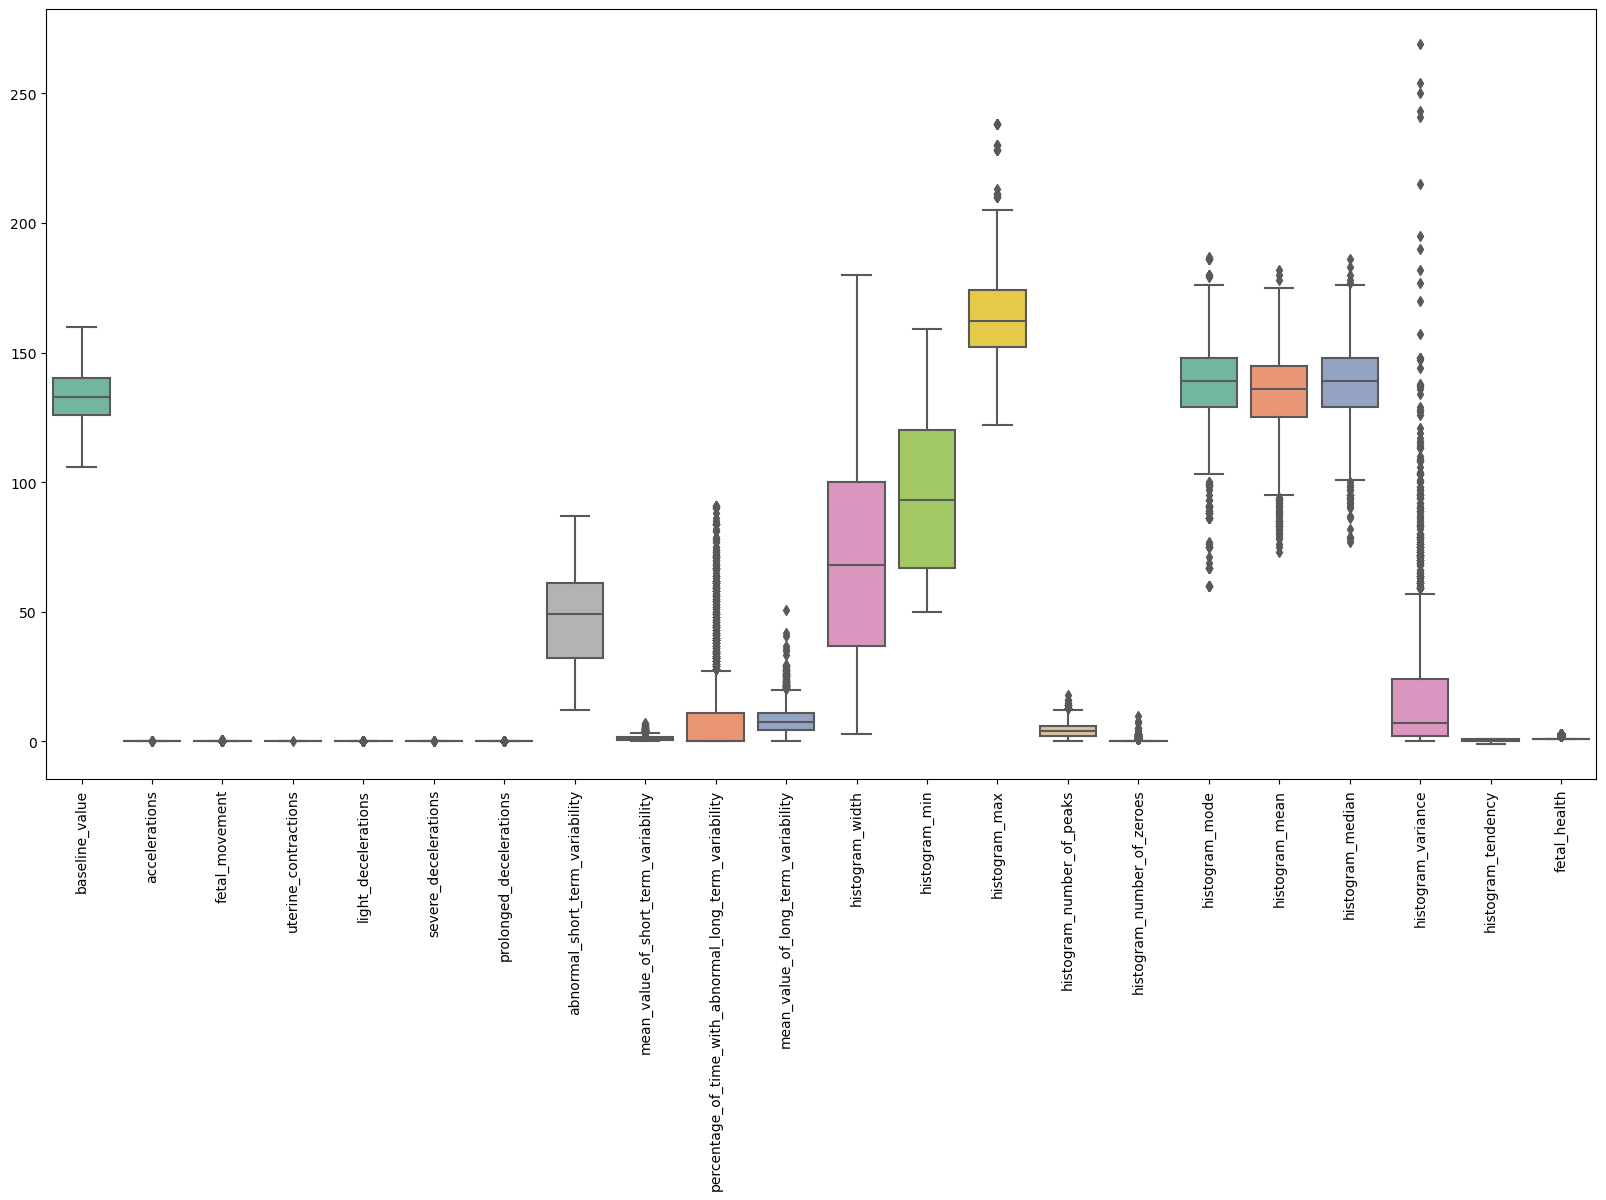

In [10]:
# Outlier checking
plt.figure(figsize=(20,10))
sns.boxplot(data = df,palette = "Set2")
plt.xticks(rotation=90)
plt.show()

Observation

* There are many columns with outliers (this can indicate a lot of columns are positive skeww or negative skeww)
* All the features are in different ranges. To fit this in a model we must scale it to the same range.

Note
* But be aware the basic rules of thumb for the outliers in question are:
* This is a measurement error or data entry error, correct the error if possible. If you can't fix it, delete the observation. In our case it was the result of a CTG report so it is less likely that this is a data entry error.

* If it is not part of the population you are studying, you can legally remove the outlier. In this case, it's all about the fetus and the experts have marked its classification. Let's stick to the expert opinion.

* So assuming that this is a natural part of the population we are studying, we shouldn't omit it.

In [11]:
# Check columns
df.columns

Index(['baseline_value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolonged_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

In [12]:
features = ['baseline_value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolonged_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency']

<AxesSubplot:xlabel='fetal_health', ylabel='count'>

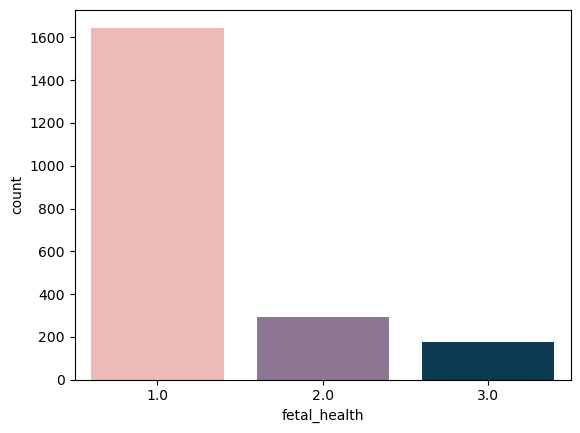

In [13]:
#first of all let us evaluate the target

colours=["#f7b2b0","#8f7198", "#003f5c"]
sns.countplot(data= df, x="fetal_health",palette=colours)

In [14]:
# Check amount of unique value
df['fetal_health'].value_counts()

1.0    1646
2.0     292
3.0     175
Name: fetal_health, dtype: int64

The majority of fetuses in this dataset are healthy, namely 1646

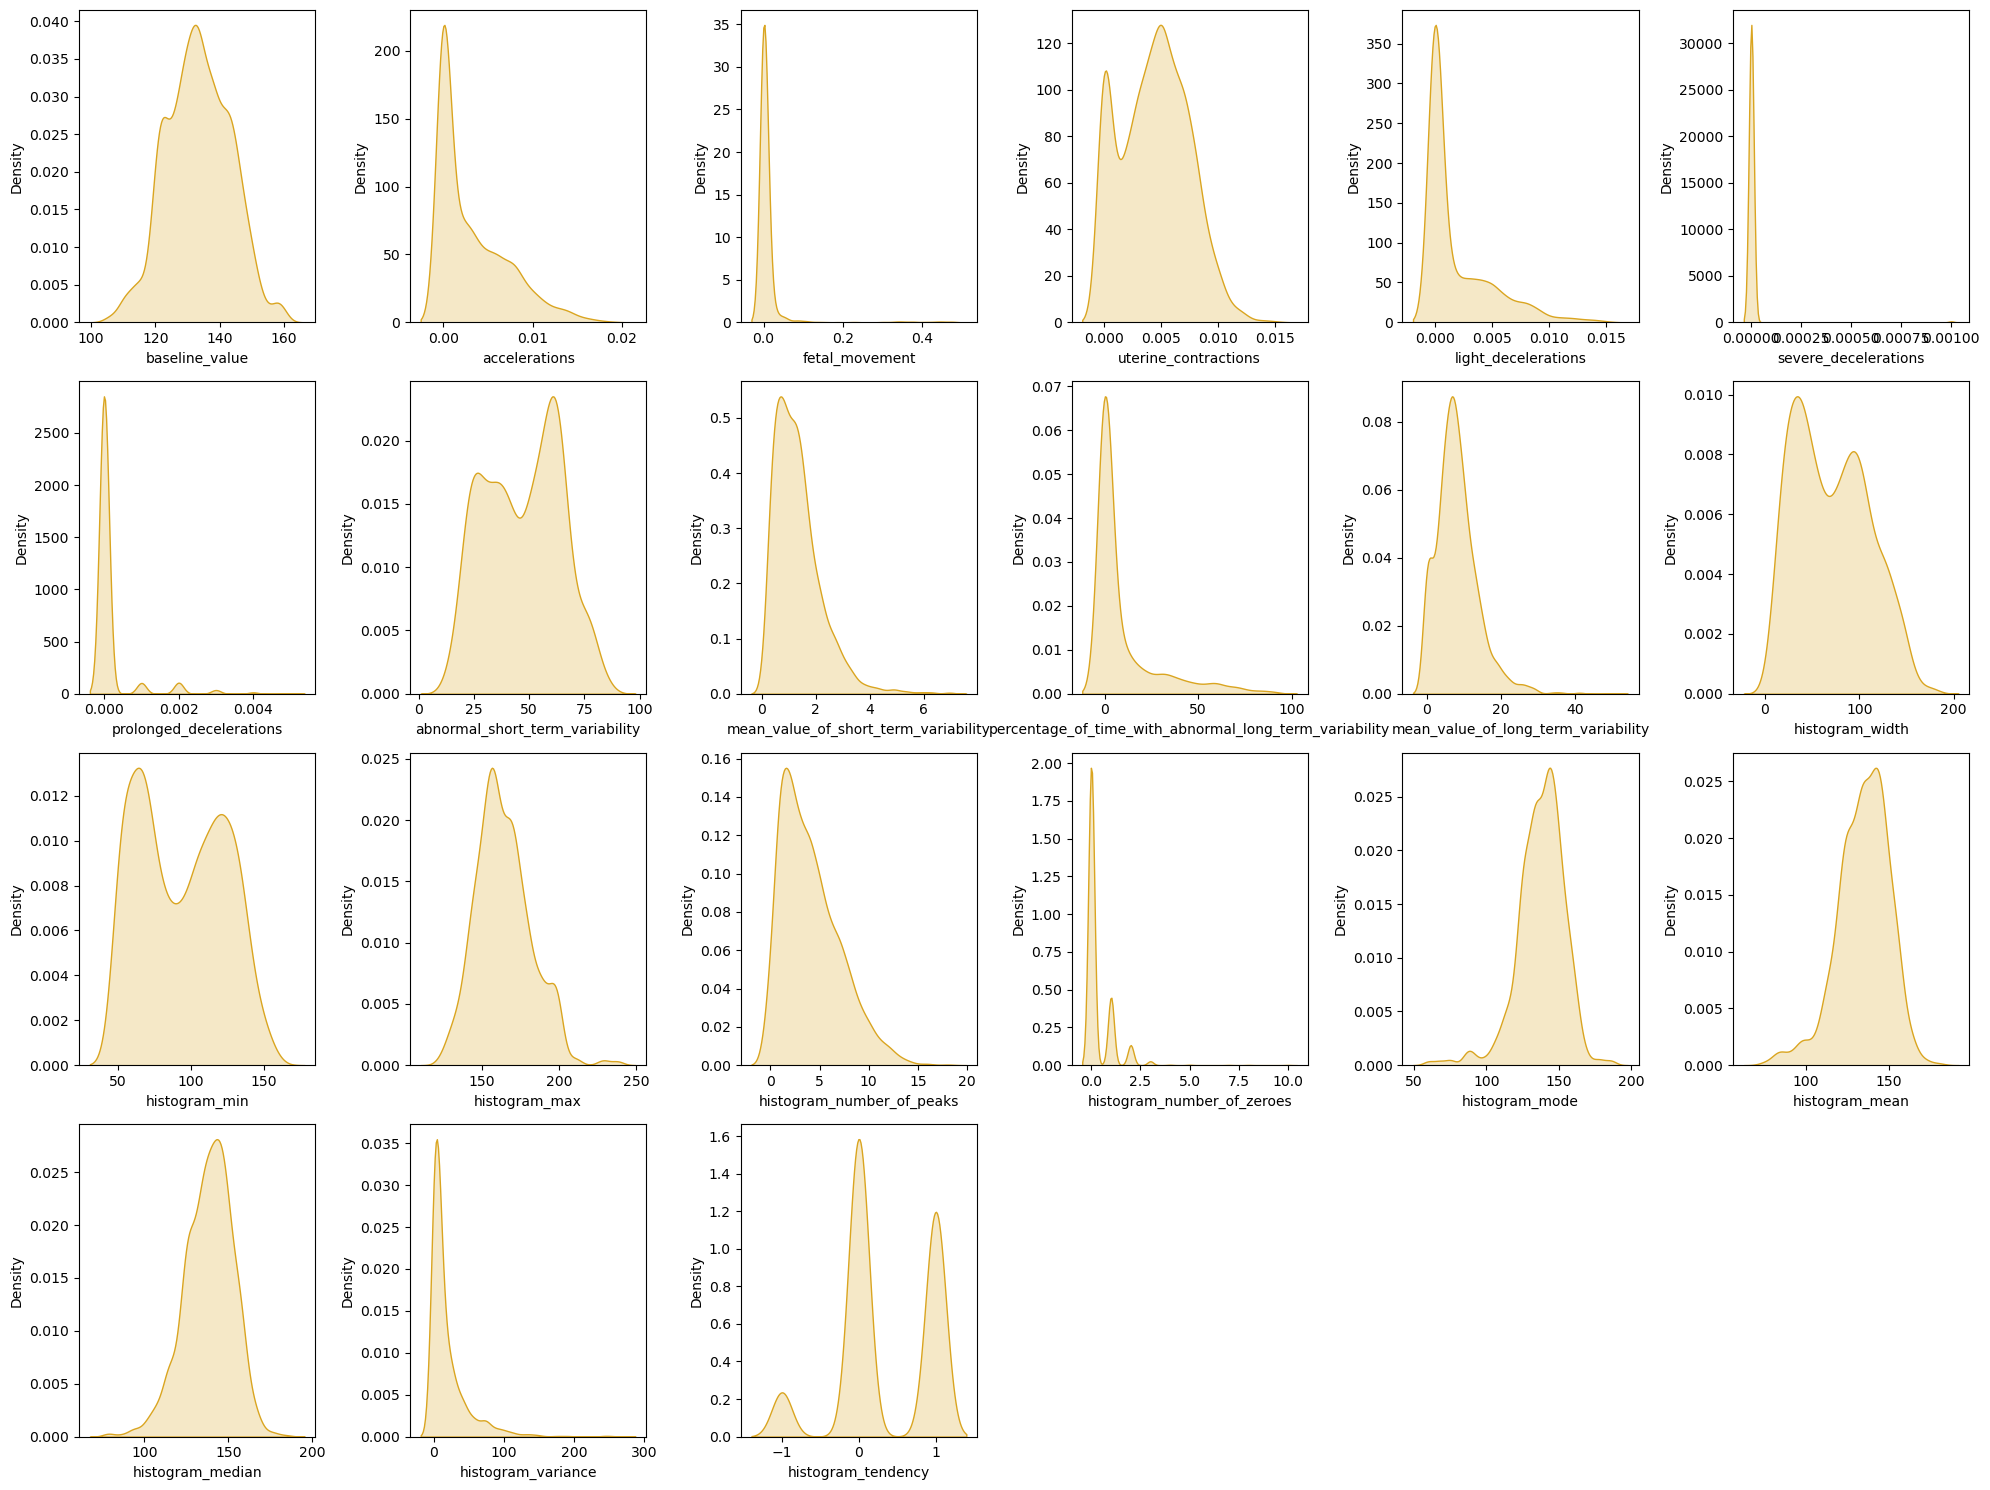

In [15]:
# adjust the figure size for better readability
plt.figure(figsize=(20,15))

for i in range(0, len(features)):
    plt.subplot(4, len(features)//4 + 1, i+1)
    sns.kdeplot(x=df[features[i]], color= 'goldenrod', fill=True)
    plt.xlabel(features[i])
    plt.tight_layout()

Observation:

1. the `baseline_value` and `histogram_median` columns are symmetrical, besides that they tend to be positively skew
2. `fetal_movement`, `light_decelerations`, `severe_decelerations`, `prolonged_decelerations`, `percentage_of_time_with_abnormal_long_term_variability`, `histogram_number_of_zeroes`, `histogram_variance` extreme positive skew
3. The majority of observed fetal heart rate acceleration, fetal_movement, and column decelerations are 0.00.
4. The majority of fetal heart rates are 133 BPM
5. `abnormal_short_term_variability` is a measure of the percentage of times that abnormal variability is observed. Most of the fetuses are said to be healthy but there are several records with a high percentage of abnormal short-term variability -> the possibility that the fetus is suspected and pathologically has a high `abnormal_short_term_variability`

## Multivariate Analysis

I will change the target to binary, where `fetal_health` 1.00 will be changed to 0 which means normal and fetal_health 2.00 and 3.00 will be changed to 1 which means risky

In [16]:
# change the value of the fetal health column
def fetal_conv(fetal_health):
  if (fetal_health == 2.00) or (fetal_health == 3.00) :
    return 1
  else:
    return 0

df['fetal_health'] = df['fetal_health'].apply(fetal_conv)
df.head()

,baseline_value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolonged_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,1
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,0


<AxesSubplot:xlabel='fetal_health', ylabel='count'>

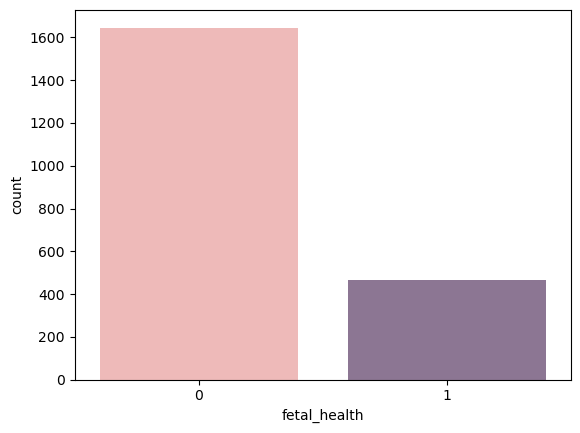

In [17]:
# Check target after changing
colours=["#f7b2b0","#8f7198", "#003f5c"]
sns.countplot(data= df, x="fetal_health",palette=colours)

In [18]:
# Amount of unique value target after changing
df['fetal_health'].value_counts()

0    1646
1     467
Name: fetal_health, dtype: int64

<AxesSubplot:>

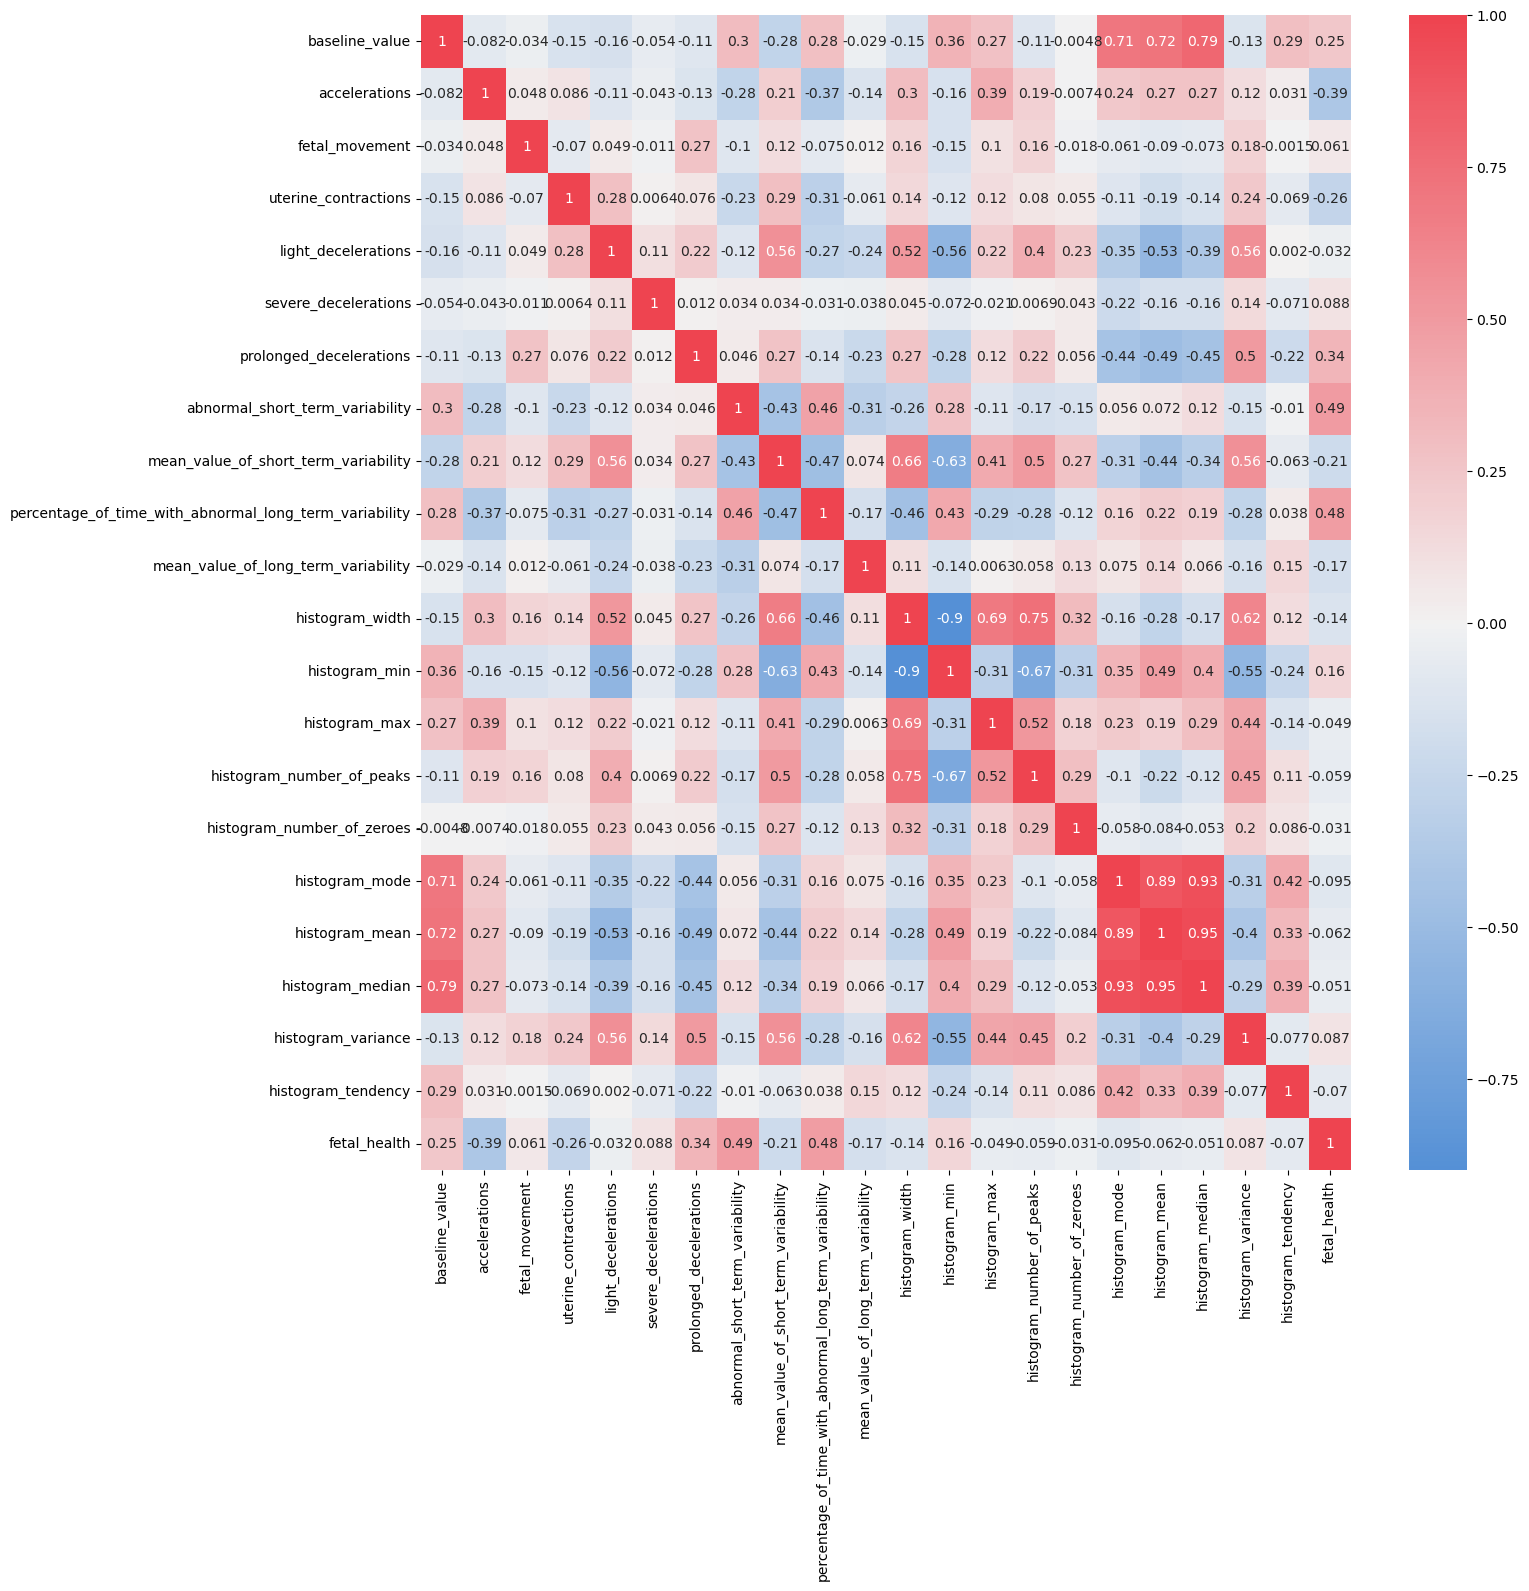

In [19]:
#correlation matrix
corrmat= df.corr()
plt.figure(figsize=(15,15))  

cmap = sns.diverging_palette(250, 10, s=80, l=55, n=9, as_cmap=True)

sns.heatmap(corrmat,annot=True, cmap=cmap, center=0)

Observation:

* Based on the correlation matrix, it is clear that `accelerations`, `prolonged_decelerations`, `abnormal_short_term_variability` and `percentage_of_time_with_abnormal_long_term_variability` are features with a high correlation with `fetal_health`.

* `histogram_mode`, `histogram_mean`, `histogram_median` are strongly correlated, this indicates that there is redundant information in the three columns

<AxesSubplot:xlabel='accelerations', ylabel='Density'>

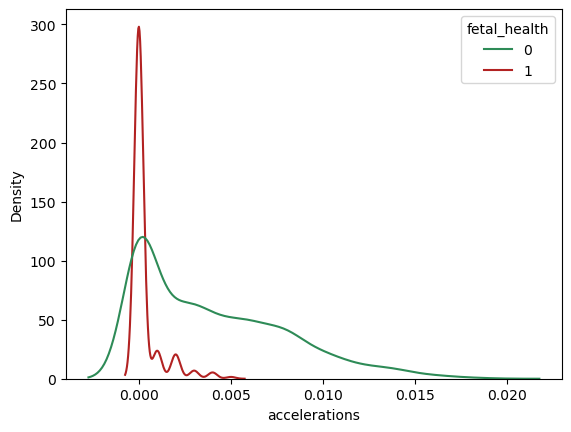

In [20]:
# KDE plot Acceleration based on fetal_health 
colours2=["seagreen", "firebrick"]
sns.kdeplot(data=df, x='accelerations', hue='fetal_health', palette=colours2)

A healthy fetus has a higher value of fetal accelerations per second than a fetus that is in danger

<AxesSubplot:xlabel='prolonged_decelerations', ylabel='Density'>

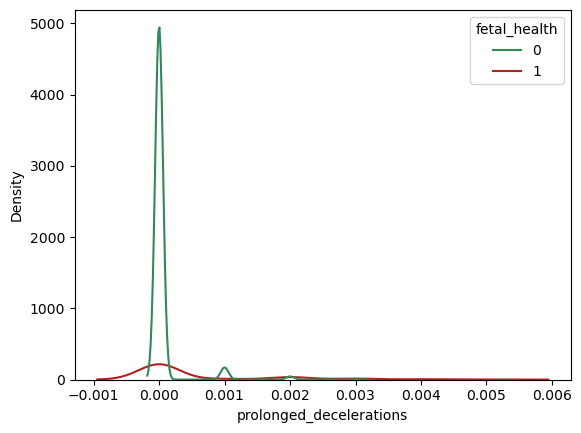

In [21]:
# KDE plot prolonged_decelerations based on fetal_health 
sns.kdeplot(data=df, x='prolonged_decelerations', hue='fetal_health', palette=colours2)

In [22]:
# Check amount of prolonged_decelerations values based on fetal_health
df.groupby(['fetal_health', 'prolonged_decelerations']).agg(amount=('fetal_health','count'))

amount
fetal_health prolonged_decelerations        
0            0.000                      1577
             0.001                        54
             0.002                        14
             0.003                         1
1            0.000                       358
             0.001                        16
             0.002                        58
             0.003                        23
             0.004                         9
             0.005                         3

`prolonged deceleration` of fetuses who are at risk tend to be higher than healthy fetuses

<AxesSubplot:xlabel='abnormal_short_term_variability', ylabel='Density'>

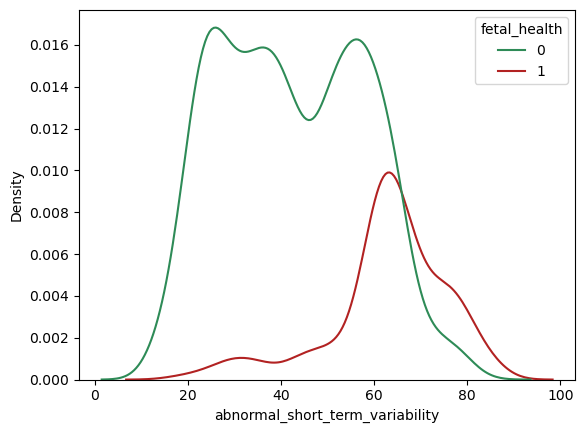

In [23]:
# KDE plot abnormal_short_term_variability based on fetal_health 
sns.kdeplot(data=df, x='abnormal_short_term_variability', hue='fetal_health', palette=colours2)

* As discussed above, the percentage value of `abnormal_short_term_variability` of normal fetuses will be lower than fetuses at risk
* The percentage value of `abnormal_short_term_variability` of normal fetuses is spread the most at +/- 23% while at risk fetuses at +/- 65%

<AxesSubplot:xlabel='percentage_of_time_with_abnormal_long_term_variability', ylabel='Density'>

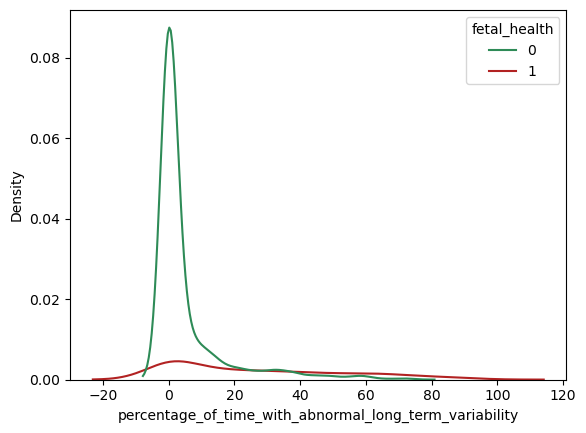

In [24]:
# KDE plot percentage_of_time_with_abnormal_long_term_variability based on fetal_health 
sns.kdeplot(data=df, x='percentage_of_time_with_abnormal_long_term_variability', hue='fetal_health', palette=colours2)

the percentage of abnormal long-term variability in both normal and at-risk fetuses is spread at most at 0%, but at-risk fetuses have a higher percentage of abnormal long-term variability

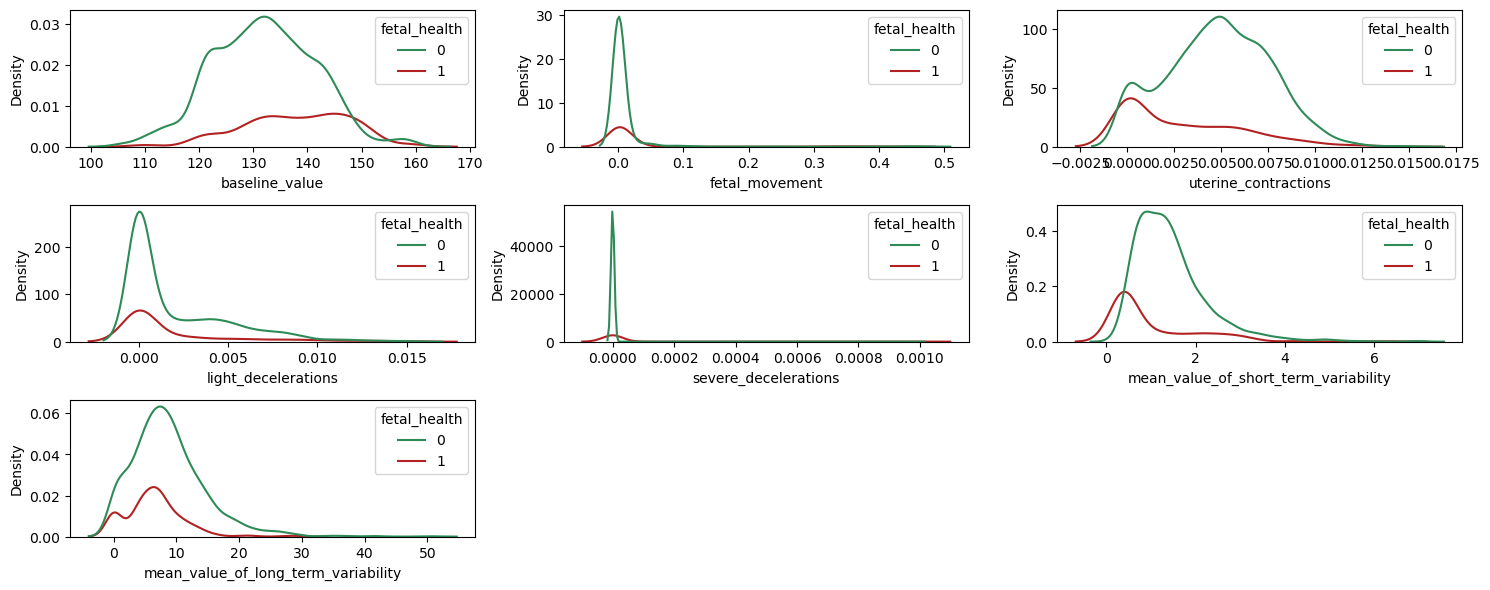

In [28]:
# KDE plot other columns based on fetal_health 
plt.figure(figsize=(15,6))

features = ['baseline_value', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'mean_value_of_short_term_variability',
       'mean_value_of_long_term_variability']
for i in np.arange(1, len(features)+1):
    plt.subplot(3, len(features)//3+1, i)
    sns.kdeplot(x=df[features[i-1]], hue=df['fetal_health'], palette=colours2)
    plt.xlabel(features[i-1])
    plt.tight_layout()

Other features that have different patterns between normal and at-risk fetuses are only `uterine_contractions` and `mean_value_of_short_term_variability`

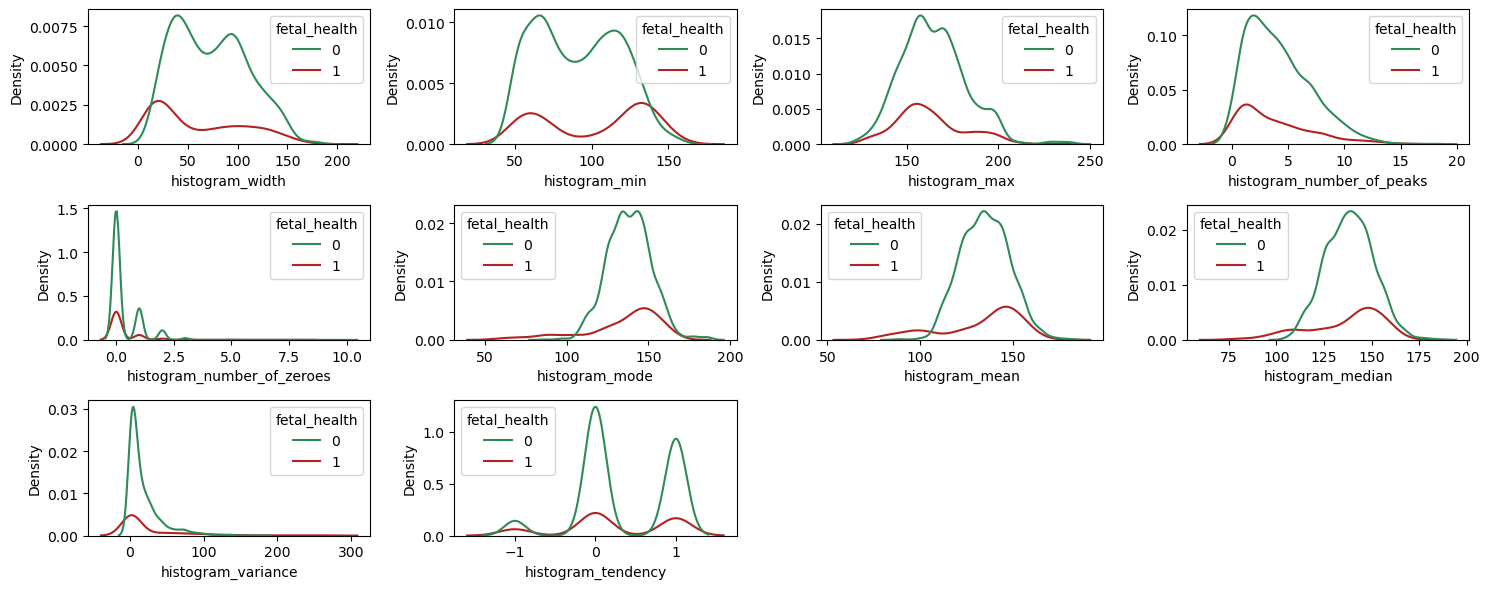

In [29]:
# KDE plots histogram-related columns based on fetal_health
plt.figure(figsize=(15,6))

histo = ['histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency']
for i in np.arange(1, len(histo)+1):
    plt.subplot(3, len(histo)//3+1, i)
    sns.kdeplot(x=df[histo[i-1]], hue=df['fetal_health'], palette=colours2)
    plt.xlabel(histo[i-1])
    plt.tight_layout()

Histogram-related features No clear relationship with fetal health

## Modeling

### 1. Model Baseline

In [30]:
# spliting features and target
X=df.drop(["fetal_health"],axis=1)
y=df["fetal_health"]

In [31]:
#spliting test and training sets
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In this baseline modeling I will use 3 classification models namely, Logistic regression, K-Neirest Neighbors, and Random Forest. I'd like to see the basic performance of the three models that we have

In [32]:
# Check baseline models
list_model = [LogisticRegression(random_state=42),
              KNeighborsClassifier(),
              RandomForestClassifier(random_state=42)
]

df_eval1 = pd.DataFrame(columns = ['Methods','recall'])

for model in list_model:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    method = str(type(model)).split('.')[-1][:-2]
    
    #recall
    recall = recall_score(y_test, y_pred)
    
    df_eval1 = df_eval1.append({'Methods': method, 'recall':recall}, ignore_index=True)
    
df_eval1

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10404\3774055806.py:17: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_eval1 = df_eval1.append({'Methods': method, 'recall':recall}, ignore_index=True)
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically p

,Methods,recall
0,LogisticRegression,0.620438
1,KNeighborsClassifier,0.759124
2,RandomForestClassifier,0.875912


C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


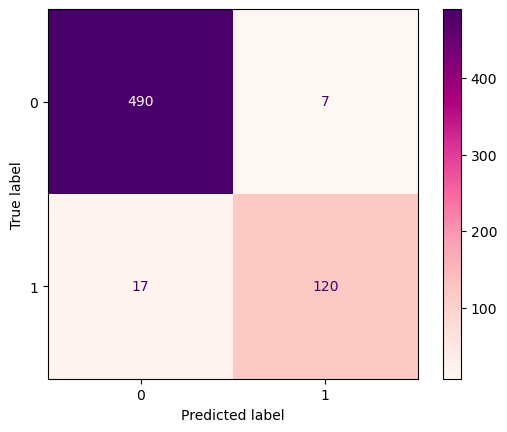

Recall score:  0.8759124087591241


In [33]:
# plotting confusion matrix
from sklearn.metrics import plot_confusion_matrix, auc

# instantiating and fitting decision tree model
rf_clf = RandomForestClassifier(random_state=42) 
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

plot_confusion_matrix(rf_clf, X_test, y_test,cmap="RdPu")
plt.show()
print('Recall score: ',recall_score(y_test, y_pred))

Observations:

* In this model I use the main recall matrix evaluation because I want to reduce False Negatives and maximize the model's performance in detecting fetuses at risk
* The 87.59% recall value means that out of 100 fetuses that are actually at risk, our model is able to detect 87 of them
* From the confusion matrix above, it can be seen that of the 127 fetuses predicted to be at risk, only 120 of them were really at risk and there were 7 False Positives
* In addition, of the 137 fetuses that were actually at risk, our model was able to predict 120 of them and missed 17, which means a false negative. This score is not good because we are dealing with the health and life outcomes of babies.

## 2. Modeling with Preprocessing

#### 1. Multicolinearity

<AxesSubplot:>

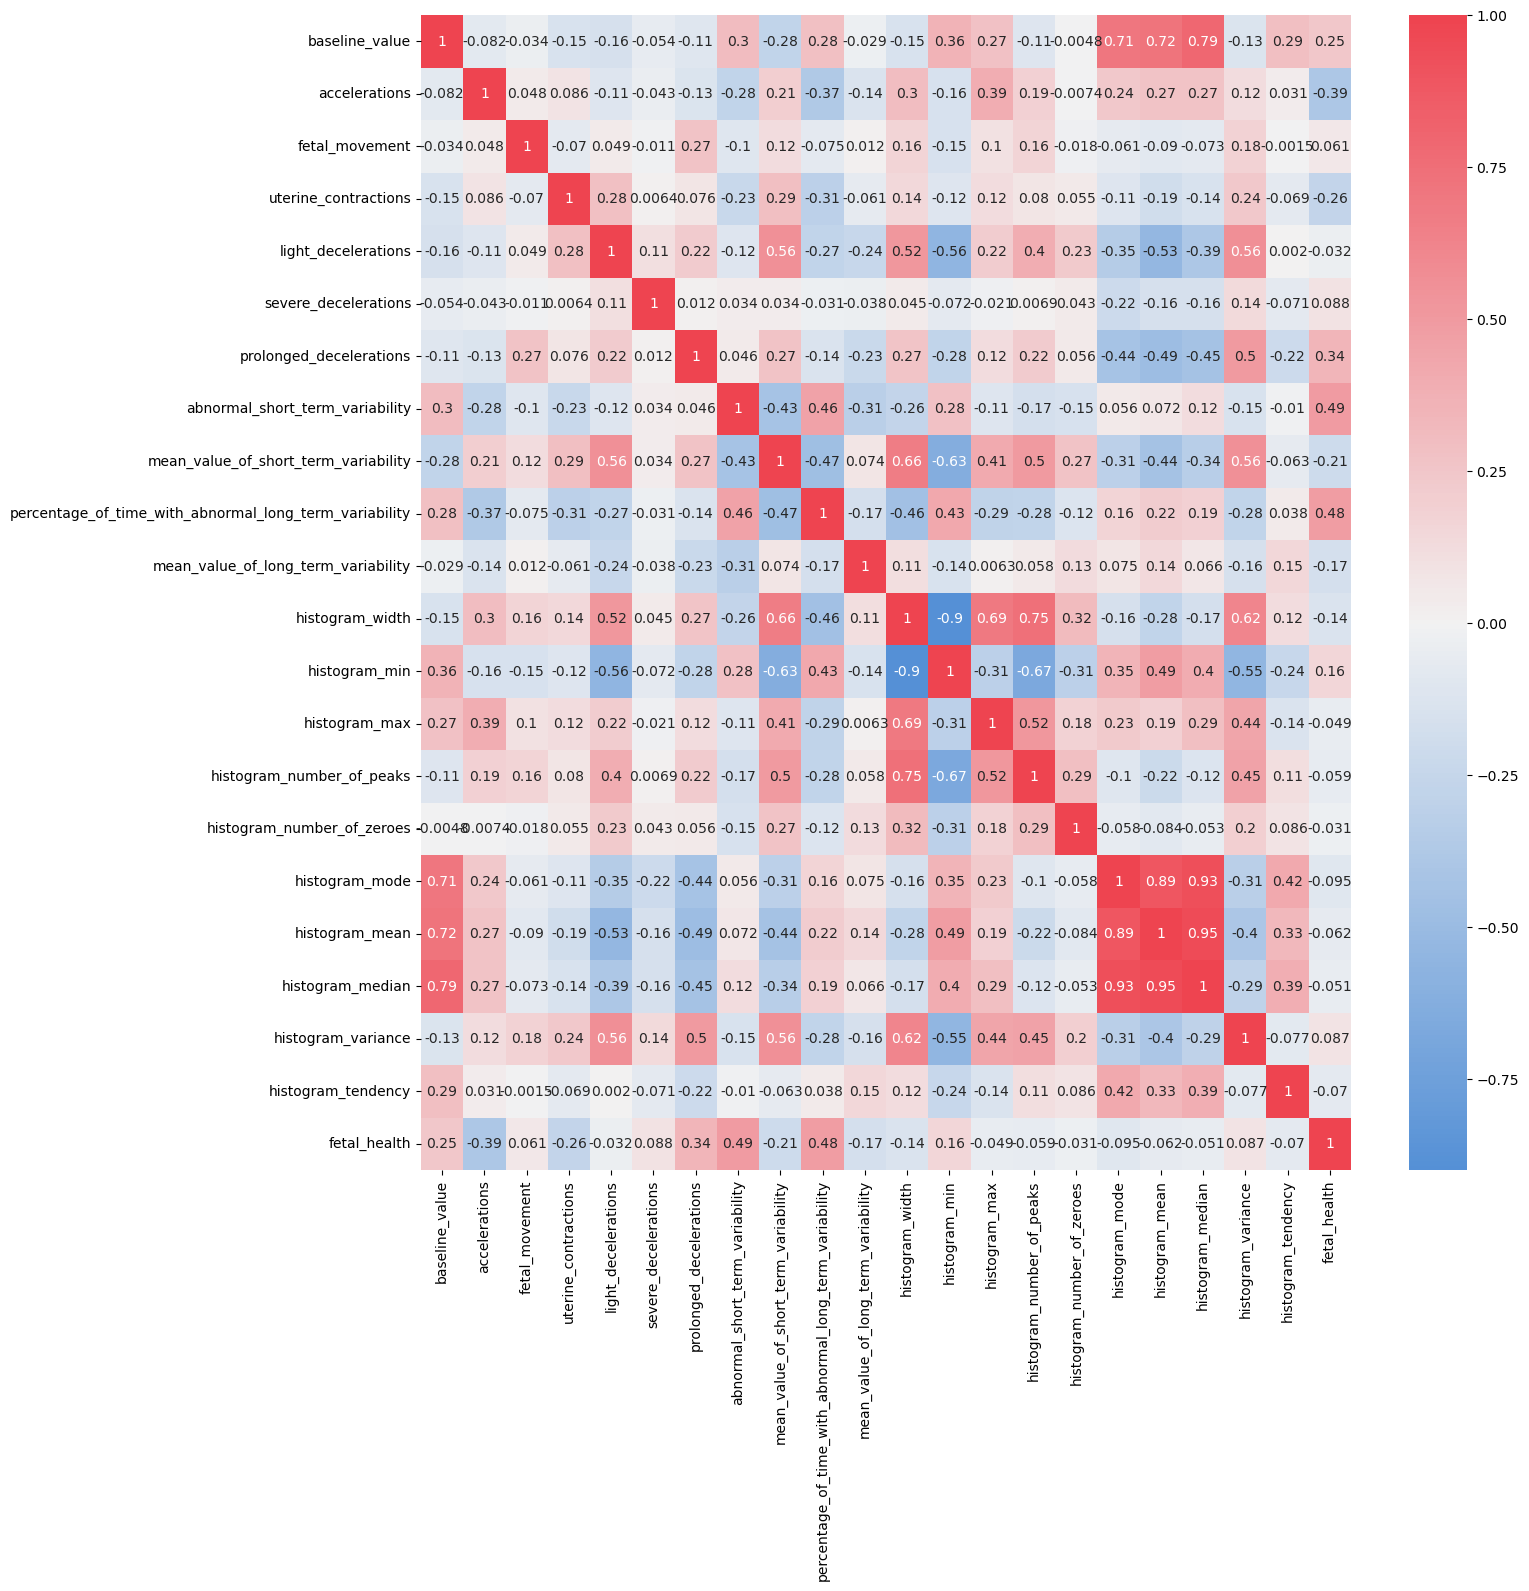

In [34]:
#correlation matrix
corrmat= df.corr()
plt.figure(figsize=(15,15))  

cmap = sns.diverging_palette(250, 10, s=80, l=55, n=9, as_cmap=True)

sns.heatmap(corrmat,annot=True, cmap=cmap, center=0)

Observation:

* The `histogram_mode`, `histogram_mean`, `histogram_median` columns are highly correlated with each other, this indicates that there is redundant information between the three. Therefore, I will drop 2 columns out of the three.
* column `histogram_mode` has the highest correlation with `fetal_health` compared to the other two columns so this column will be maintained

In [35]:
# drop columns which is multicolinearity
df = df.drop(['histogram_mean', 'histogram_median' ], axis=1)
df.head(3)

,baseline_value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolonged_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,73.0,1.0,1
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,12.0,0.0,0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,13.0,0.0,0


#### 2. Split training and test sets

In [36]:
# spliting features and target
X=df.drop(["fetal_health"],axis=1)
y=df["fetal_health"]

In [37]:
#spliting test and training sets
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

#### 3. Scaling

In [38]:
#Set up a standard scaler for the features
col_names = list(X_train.columns)
s_scaler = StandardScaler()
X_scale = s_scaler.fit_transform(X) 

In [39]:
# Set to be a data_frame for boxplot
df_sc = pd.DataFrame(X_scale, columns=col_names)

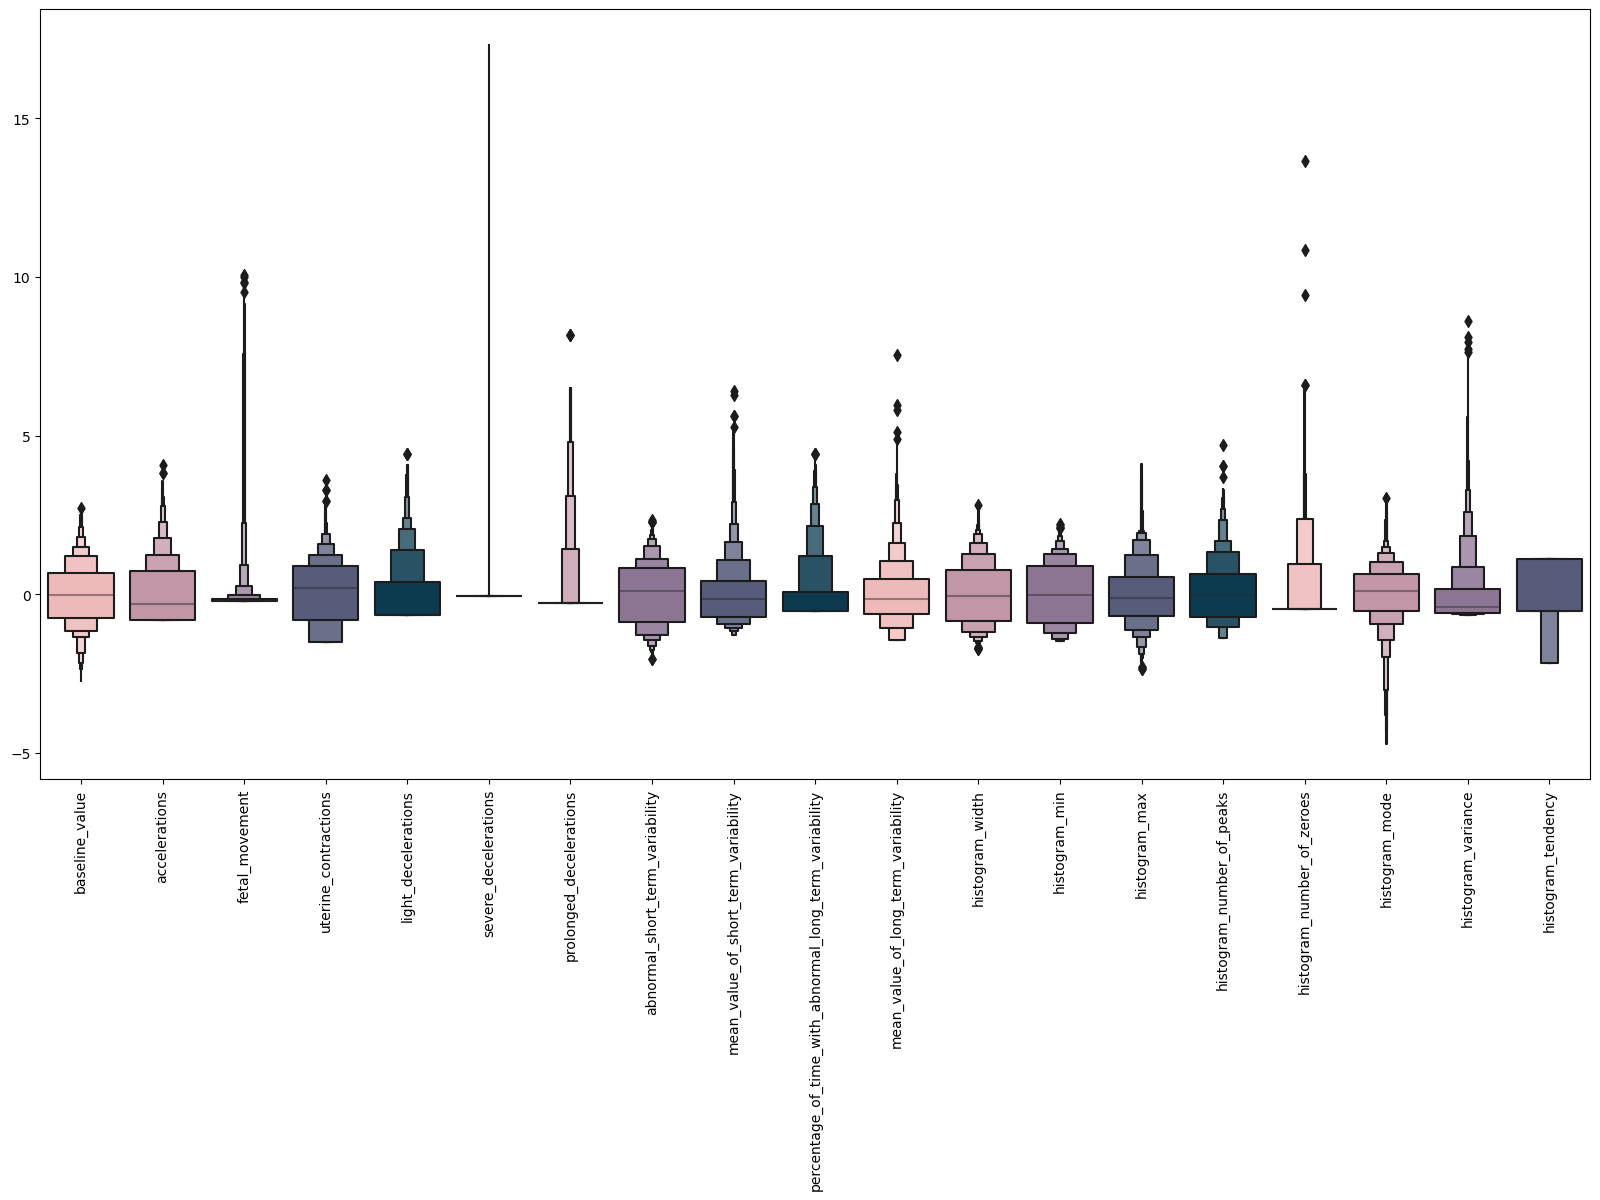

In [40]:
#looking at the scaled features
plt.figure(figsize=(20,10))
shades =["#f7b2b0","#c98ea6","#8f7198","#50587f", "#003f5c"]
sns.boxenplot(data = df_sc,palette = shades)
plt.xticks(rotation=90)
plt.show()

Observation:

* In the EDA stage above I have discussed the range of features that have different ranges, so I think it is necessary to do scaling in preprocessing before modeling
* With this processing I hope the model will be trained faster(lighter computation) and better performance
* Because in the next stage I will do oversampling with the SMOTE method which generates data based on distance, this scaling process is very useful 

#### 4. Imbalance Handling

<AxesSubplot:xlabel='fetal_health', ylabel='count'>

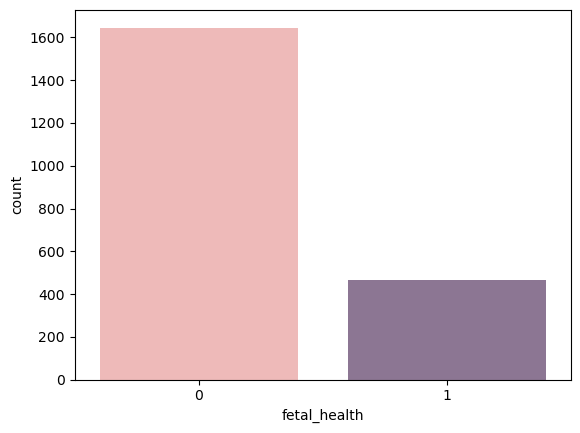

In [41]:
# evaluate the target and find out if our data is imbalanced or not

colours=["#f7b2b0","#8f7198"]
sns.countplot(data= df, x="fetal_health",palette=colours)

Observation:

* It can be seen from the histogram above that there are far more `fetal_health` with a value of 0 (Normal) than those with a value of 1 (At Risk), so it is necessary to carry out imbalance handling
* I will choose the SMOTE method because the amount of data is small so it will avoid overfitting, besides that I also don't want duplicates in the dataset

In [42]:
# SMOTE Training data
X_train, y_train = over_sampling.SMOTE().fit_resample(X_train, y_train)
df_oversampling_smote = pd.concat([X_train, y_train], axis=1)
df_oversampling_smote['fetal_health'].value_counts()

0    1149
1    1149
Name: fetal_health, dtype: int64

Note:
* I only do SMOTE for the train data so that the test data that we test in this model truly represents the original data
* The train data is already balanced (target) so that the model performance will be better and can use the accuracy evaluation matrix

#### 5. Hyperarameter tuning Logistic Regression

In [43]:
# define random forest classifier model
logred_clf = LogisticRegression(random_state=42)

In [44]:
%%time
from sklearn.model_selection import GridSearchCV

parameters = {
    'penalty': ['l1', 'l2'],
    'C':np.logspace(-4,4,20)
}

# note: we use recall
logred_clf_gridcv = GridSearchCV(logred_clf, parameters, cv=5, scoring='recall')
logred_clf_gridcv.fit(X_train, y_train)

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

Wall time: 11.3 s


C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2']},
             scoring='recall')

In [45]:
# the results of logistic regression
cv_result = pd.DataFrame(logred_clf_gridcv.cv_results_)
retain_cols = ['params','mean_test_score','rank_test_score']
cv_result[retain_cols].sort_values('rank_test_score').head()

,params,mean_test_score,rank_test_score
39,"{'C': 10000.0, 'penalty': 'l2'}",0.859875,1
1,"{'C': 0.0001, 'penalty': 'l2'}",0.859024,2
25,"{'C': 11.288378916846883, 'penalty': 'l2'}",0.857262,3
17,"{'C': 0.23357214690901212, 'penalty': 'l2'}",0.857262,4
37,"{'C': 3792.690190732246, 'penalty': 'l2'}",0.855531,5


Observation:

* In my Hyperparameter tuning logistic regression model I use 2 parameters namely the value of `C` and `penalty`
* A total of 40 combinations were tried in this tuning and produced the best performance with the combination {'C': 10000.0, 'penalty': 'l2'} which resulted in a recall value of 85.98%

#### 6. Hyperarameter tuning K-Neirest Neighbors

In [46]:
# define the estimator/model
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()

In [47]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

parameters = {
    'n_neighbors': (2,3,4,5,6,7,8)
}

knn_clf_gridcv = GridSearchCV(knn_clf, parameters, cv=5, scoring='recall')
knn_clf_gridcv.fit(X_train, y_train)

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims`

C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\ASUS\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims`

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': (2, 3, 4, 5, 6, 7, 8)},
             scoring='recall')

In [48]:
# the compact results of KNN
cv_result = pd.DataFrame(knn_clf_gridcv.cv_results_)
retain_cols = ['params','mean_test_score','rank_test_score']
cv_result[retain_cols].sort_values('rank_test_score')

,params,mean_test_score,rank_test_score
1,{'n_neighbors': 3},0.963471,1
3,{'n_neighbors': 5},0.953898,2
5,{'n_neighbors': 7},0.948669,3
2,{'n_neighbors': 4},0.938230,4
0,{'n_neighbors': 2},0.936499,5
6,{'n_neighbors': 8},0.934748,6
4,{'n_neighbors': 6},0.932136,7


Observation:

* In the Hyperparameter tuning of the KNN model I use the parameter number of neighbors (`n`)
* A total of 7 parameter values were tried in this tuning and produced the best performance with 3 neighbors which resulted in a recall value of 96.34%
* Here proves that the larger the neighbor value is not always positively correlated with the model performance

#### 7. Hyperarameter tuning Random Forest

In [49]:
# define random forest classifier model
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)

In [50]:
%%time
from sklearn.model_selection import GridSearchCV

parameters = {
    'n_estimators': (10,20,30,40,50),
    'max_depth':(4,6,8,12,14,16)
}

# note: we use recall
rf_clf_gridcv = GridSearchCV(rf_clf, parameters, cv=5, scoring='recall')
rf_clf_gridcv.fit(X_train, y_train)

Wall time: 19.7 s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': (4, 6, 8, 12, 14, 16),
                         'n_estimators': (10, 20, 30, 40, 50)},
             scoring='recall')

In [51]:
# the results of Random Forest
cv_result = pd.DataFrame(rf_clf_gridcv.cv_results_)
retain_cols = ['params','mean_test_score','rank_test_score']
cv_result[retain_cols].sort_values('rank_test_score').head()

,params,mean_test_score,rank_test_score
29,"{'max_depth': 16, 'n_estimators': 50}",0.978257,1
19,"{'max_depth': 12, 'n_estimators': 50}",0.977388,2
27,"{'max_depth': 16, 'n_estimators': 30}",0.975648,3
24,"{'max_depth': 14, 'n_estimators': 50}",0.975648,3
23,"{'max_depth': 14, 'n_estimators': 40}",0.975648,3


Observation:

* In the Random Forest Hyperparameter tuning model I use 2 parameters, namely the number of trees (`n_estimators`) and the allowed tree height (`max_depth`)
* A total of 30 parameter combinations were tried in this tuning and produced the best performance with the combination {`max_depth`: 16, `n_estimators`: 50} which resulted in a recall value of 97.82%

After performing Hyperparameter tuning on the three models above, it was found that the best model is the Random Forest with parameters {max_depth: 16, n_estimators: 50} which produces a recall value of 97.82%

# Evaluation

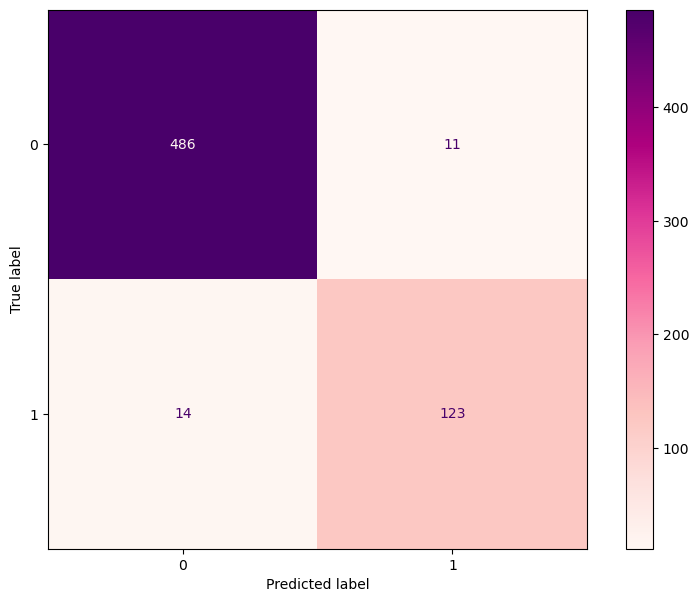

In [57]:
# plotting confusion matrix
fig, ax = plt.subplots(figsize=(10,7))
y_pred = rf_clf_gridcv.best_estimator_.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=rf_clf_gridcv.best_estimator_.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rf_clf_gridcv.best_estimator_.classes_)
disp.plot(ax=ax, cmap="RdPu")
plt.show()

* 0 : Normal 
* 1 : Berisiko 

Observation 

* 486 -> 486 with true label Normal, predicted Normal = (True Negative)
* 11 -> 11 with true label Normal, predicted risky = (False Positive)
* 14 -> 14 with true labels are risky, predicted Normal = (False Negative)
* 123 -> 123 with true label risk, predicted risk = (True Positive)

In [53]:
# classification report
from sklearn.metrics import classification_report
y_pred = rf_clf_gridcv.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       497
           1       0.92      0.90      0.91       137

    accuracy                           0.96       634
   macro avg       0.94      0.94      0.94       634
weighted avg       0.96      0.96      0.96       634



**Positive class for fetal health is 'Risky' and negative class is 'Normal'.**
* With the best model in this project we get a recall value of 90%, this is a pretty good model for predicting fetal health. Referring to our initial goal to get a model that is able to have as few false negative values as possible because this concerns the health of the mother-fetus so it is better to prevent than to treat.
* A 90% recall value means that out of 100 fetuses that are actually at risk, our model is able to detect 90 of them
* Even though we focus on models with high recall values, the model works quite well with a precision of 92%, which means that out of 100 fetuses that are predicted to be at risk, there are 92 fetuses that are really at risk. This is also indicated by the F1 model score of 91%.
* An accuracy value of 96% means that our model is able to correctly predict the health of the fetus in 96 out of 100 fetuses.

## Conclusion & Recomendation

**Conclusion**

Cardiotocogram data provide easily accessible and interpretable insight into fetal health outcomes. The machine learning model is able to quickly predict if the fetus is in a distressed state using CTG data with high recall, precision and accuracy values. With the ability of machine learning models to determine the health of the fetus and the knowledge of obstetricians, it is hoped that the health of the fetus and mother can be known precisely so as to effectively reduce the problem of fetal death.

**Recommendation**

1. Machine learning with CTG data is able to predict the health of the fetus and has a fairly good performance with a recall value of 90% and 96% accuracy. This can quickly detect the health condition of the fetus. I recommend that Machine learning be applied to the classification of fetal health, so that the analysis of CTG results is faster. Therefore, CTG can be done as often as possible in pregnant women because interpretation is faster, so that pregnant women and doctors know for sure the condition of the fetus so they can provide proper treatment
2. I recommend that healthcare providers pay attention to all measures of fetal heart rate, as it is the strongest predictor of fetal health outcomes at risk. These measures include the percentage of time with abnormal short-term variability, the percentage of time with abnormal long-term variability, and prolonged decelerations.
3. My last recommendation is the prediction of machine learning as a tool that makes it easier for obstetricians to determine fetal health based on CTG data, therefore it is necessary to double check these predictions because there are still deficiencies in this machine learning